# Lab Assignment 5: Restoring Clean Images from Noisy Images

## Cleaning Up the Bayes' Theorem Image
Now it's your turn! It's time to design an implement your solution to clean up `./figures/Bayes-noise.png`. Use the pre-processed `./figures/Bayes-pre-processed.png`, provided. Be careful not to over-write these files. Save your cleaned up image with a different file name (for example, `./figures/Bayes-denoised.png`) to display and check your work. **DO NOT use the cautionary tale image, `./bad_figures/Bayes-incorrectly-pre-processed.png` as your starting point.**

You are welcome to copy/paste any of the starter code above in your solution.

The problem statement above is copied here for your convenience.

### Revisiting the Problem Statement:
![A clean image, the corrupted image, and a pairwise MRF](./figures/problem_statement_diagram.png)

The goal of this problem is to recover the clean image (a) from a noisy input (b). Of course, we cannot recover (a) exactly since information has been lost in the noise. The graphical model we use is a pairwise MRF as shown in (c). A pixel has four neighbors. We are going to use Markov Random Fields (MRFs) to model the distribution of natural images and restore the clean image given an noisy input image. Observed image $y_i \in \{-1,+1\}$, and $i = 1,\cdots,D$ indexes pixels in the lattice. The
original noise free image is $x_i \in \{-1, +1\}$. The noisy image $y_i$ is obtained by randomly flipping the sign of pixels with some probability (10% of pixels, in this case).

There are two types of cliques in this MRF. For $\{x_i,y_i\}$, we define the energy function as $-\eta x_i y_i\ (\eta > 0)$.  Lower energy is achieved when $x_i$ and $y_i$ have the same sign and a higher energy when they have the opposite sign. For a pair of variables $\{x_i, x_j\}$ where $i$ and $j$ are indices of neighboring pixels, we want the energy to be lower when they have the same sign than when they have opposite sign. So the energy function is $-\beta x_i j_i\ (\beta > 0)$. Lastly, we have an energy term $hx_i$ for each pixel $i$ to bias the model towards one particular sign (either $+$ or $−$).

The final energy function for the model takes the form

$E(\vec{x}\vec{y}) = h\displaystyle\sum\limits_i x_i - \beta \displaystyle\sum\limits_{\{i,j\}} x_ix_j - \eta\displaystyle\sum\limits_i x_iy_i$

which defines a joint distribution over $\vec{x}$ and $\vec{y}$ given by

$p(\vec{x},\vec{y}) = \dfrac{1}{\vec{\mathcal{Z}}}exp\{-E(\vec{x}\vec{y})\}$

Now implement Coordinate-descent algorithm as below on this:
1. Initialize $\{x_i\} (x_i = y_i)$
2. Loop over $\{x_i\}$. For each $x_i$, fix the neighborhood and see whether $−x_i$ would
decrease the energy. If so, then flip $x_i$; otherwise, continue.
3. Stop when no changes can be made for $x$.

Now make some initial guess for the parameters $h$, $\beta$, $\eta$ so that the above algorithm converges and then adjust them until you can get up to 96% recovery or better. Record your parameter values and the number of iterations when you acheived this recovery.

Save the recovered image and submit it along with your code. The clean image, noisy image, and now the pre-processed images are included in the `figures` folder : `./figures/Bayes.png`, `./figures/Bayes-noise.png`, and `./figures/Bayes-pre-processed.png`

### Write and Run your Own Code

## Import Libraries
In addition to the `IPython.display` and the `PIL` packages, if you would like to use other libraries in this notebook, please include them below.

In [20]:
## ===============================================================
## Library Imports:
## ===============================================================
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Image display functionality
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
from IPython.display import Image as disp

## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Pixel Manipulation
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
from PIL import Image

## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Additional Libraries?
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#### Please insert other libraries as needed.

#### I recommend to use these as well; feel free to use different / remove if unnecessary
import numpy as np
import matplotlib.pyplot as plt
import copy
import os

Image shape: (489, 654)
Noisy image  → fraction +1 pixels: 0.7296

Grid search over β and η
     β      η   iters   accuracy
-----------------------------------

Iter   Changes   Accuracy    Patience
------------------------------------------
   1     86465    0.8029     0/5
   2         0    0.8029     1/5
   3         0    0.8029     2/5
   4         0    0.8029     3/5
   5         0    0.8029     4/5
   6         0    0.8029     5/5

Converged: 5 consecutive zero-change sweep(s) at iter 6.
   0.5    0.5       6     80.29%
  Saved → O:\ENGS106\coding-assignment5\coding-assignment5\figures\Bayes-denoised_b0.5_e0.5.png
  Figure → O:\ENGS106\coding-assignment5\coding-assignment5\figures\comparison_b0.5_e0.5.png

Iter   Changes   Accuracy    Patience
------------------------------------------
   1     86465    0.8029     0/5
   2         0    0.8029     1/5
   3         0    0.8029     2/5
   4         0    0.8029     3/5
   5         0    0.8029     4/5
   6         0    0.8029     5/5

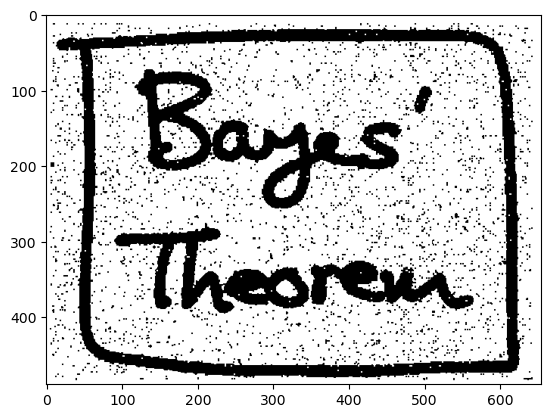

In [21]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# ============================================================
# Module 1: Load images and convert to black and white
# ============================================================

def load_image_as_binary(path):
    """Load an image and convert to binary {-1, +1} array."""
    img = Image.open(path).convert('L')          # grayscale
    arr = np.array(img, dtype=np.float64)
    # Threshold at midpoint: pixel >= 128 → +1, else → -1
    binary = np.where(arr >= 128, 1.0, -1.0)
    return binary

# Load the pre-processed noisy image as starting point
FIGURES_DIR = r'O:\ENGS106\coding-assignment5\coding-assignment5\figures'

noisy_path  = os.path.join(FIGURES_DIR, 'Bayes-pre-processed.png')
clean_path  = os.path.join(FIGURES_DIR, 'Bayes.png')   # ground truth (eval only)
output_path = os.path.join(FIGURES_DIR, 'Bayes-denoised.png')

y = load_image_as_binary(noisy_path)   # observed noisy image
try:
    x_clean = load_image_as_binary(clean_path)   # ground truth (for evaluation)
    has_clean = True
except FileNotFoundError:
    has_clean = False
    print("Clean image not found – accuracy evaluation will be skipped.")

print(f"Image shape: {y.shape}")
print(f"Noisy image  → fraction +1 pixels: {(y == 1).mean():.4f}")

# ============================================================
# Module 2: Coordinate-descent algorithm (ICM – Iterated
#           Conditional Modes) on the pairwise MRF
# ============================================================

def compute_local_field(x, i, j, neighbors, h, beta, eta, y):
    """
    Compute the effective local field for pixel (i,j).
    Flipping x[i,j] from s to -s decreases energy iff local_field * s < 0,
    i.e. we should set x[i,j] = sign(local_field).

    local_field = -h  +  beta * sum_{k in N(i,j)} x[k]  +  eta * y[i,j]
    (derived by comparing E(x_i=+1) vs E(x_i=-1))
    """
    neighbor_sum = sum(x[ni, nj] for ni, nj in neighbors)
    return -h + beta * neighbor_sum + eta * y[i, j]

def get_neighbors(i, j, rows, cols):
    """Return the 4-connected neighbours of pixel (i,j)."""
    nbrs = []
    if i > 0:        nbrs.append((i-1, j))
    if i < rows - 1: nbrs.append((i+1, j))
    if j > 0:        nbrs.append((i, j-1))
    if j < cols - 1: nbrs.append((i, j+1))
    return nbrs

def coordinate_descent_mrf(y, h=0.0, beta=1.0, eta=2.1, max_iter=50,
                            patience=1, x_clean=None):
    """
    Coordinate-descent (ICM) denoising.

    Parameters
    ----------
    y        : 2-D array of {-1, +1}  – observed noisy image
    h        : scalar bias term
    beta     : coupling strength between neighbouring pixels
    eta      : coupling strength between x_i and y_i
    max_iter : maximum number of full sweeps
    patience : stop only after this many consecutive zero-change sweeps
               (default=1; set >1 to avoid premature convergence)
    x_clean  : optional ground-truth array for accuracy tracking

    Returns
    -------
    x                : denoised image array of {-1, +1}
    n_iter           : number of sweeps performed
    accuracy_history : list of per-sweep accuracies (if x_clean provided)
    """
    rows, cols = y.shape
    x = y.copy()                         # Step 1 – initialise x_i = y_i

    accuracy_history = []
    if x_clean is not None:
        accuracy_history.append((x == x_clean).mean())

    print(f"\n{'Iter':>4}  {'Changes':>8}  {'Accuracy':>9}  {'Patience':>10}")
    print("-" * 42)

    zero_streak = 0                      # consecutive zero-change sweep counter

    for sweep in range(1, max_iter + 1):
        changes = 0

        # Step 2 – loop over every pixel
        for i in range(rows):
            for j in range(cols):
                nbrs = get_neighbors(i, j, rows, cols)
                lf   = compute_local_field(x, i, j, nbrs, h, beta, eta, y)
                new_val = 1.0 if lf > 0 else -1.0
                if new_val != x[i, j]:
                    x[i, j] = new_val
                    changes += 1

        acc = (x == x_clean).mean() if x_clean is not None else float('nan')
        if x_clean is not None:
            accuracy_history.append(acc)

        # Track consecutive zero-change sweeps
        if changes == 0:
            zero_streak += 1
        else:
            zero_streak = 0              # reset if any pixel was flipped

        print(f"{sweep:>4}  {changes:>8}  {acc:>8.4f}  {zero_streak:>4}/{patience}")

        # Step 3 – stop only after `patience` consecutive zero-change sweeps
        if zero_streak >= patience:
            print(f"\nConverged: {patience} consecutive zero-change sweep(s) at iter {sweep}.")
            break
    else:
        print(f"\nReached max_iter={max_iter} without convergence.")

    return x, sweep, accuracy_history

# ============================================================
# Module 3: Grid search over parameters + display/save each result
# ============================================================

def binary_to_uint8(arr):
    """Convert {-1,+1} array to 0/255 uint8 for saving."""
    return ((arr + 1) / 2 * 255).astype(np.uint8)

def save_and_plot(x_out, y, x_clean, h, beta, eta, n_it, final_acc,
                  figures_dir, show_plot=True):
    """Save denoised image and plot a side-by-side comparison for one parameter set."""

    # ── 1. Save denoised PNG ──────────────────────────────────
    fname = f'Bayes-denoised_b{beta}_e{eta}.png'
    save_path = os.path.join(figures_dir, fname)
    Image.fromarray(binary_to_uint8(x_out)).save(save_path)
    print(f"  Saved → {save_path}")

    # ── 2. Side-by-side comparison figure ────────────────────
    ncols = 3 if x_clean is not None else 2
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

    axes[0].imshow(binary_to_uint8(y), cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Noisy Input')
    axes[0].axis('off')

    axes[1].imshow(binary_to_uint8(x_out), cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'Denoised\nh={h}, β={beta}, η={eta}\n'
                      f'iters={n_it},  acc={final_acc*100:.2f}%')
    axes[1].axis('off')

    if x_clean is not None:
        axes[2].imshow(binary_to_uint8(x_clean), cmap='gray', vmin=0, vmax=255)
        axes[2].set_title('Ground Truth')
        axes[2].axis('off')

    plt.suptitle(f'β={beta}  η={eta}  →  {final_acc*100:.2f}% accuracy',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    fig_fname = f'comparison_b{beta}_e{eta}.png'
    fig_path  = os.path.join(figures_dir, fig_fname)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close()
    print(f"  Figure → {fig_path}")


# ── Grid search ──────────────────────────────────────────────
H_LIST    = np.arange(-2.0, 2.1, 0.5)
BETA_LIST = np.arange(0.5, 4.1, 0.5)
ETA_LIST  = np.arange(0.5, 4.1, 0.5)

print("\n" + "="*60)
print("Grid search over β and η")
print("="*60)
print(f"{'β':>6} {'η':>6} {'iters':>7} {'accuracy':>10}")
print("-"*35)

best_acc, best_params, best_img = 0, None, None

for h in H_LIST:
    for beta in BETA_LIST:
        for eta in ETA_LIST:
            x_out, n_it, _ = coordinate_descent_mrf(
                y, h=h, beta=beta, eta=eta,
                max_iter=100,
                patience = 5,
                x_clean=x_clean if has_clean else None
            )

            # Compute accuracy directly from final output (avoids history-list bug)
            final_acc = (x_out == x_clean).mean() if has_clean else float('nan')
            print(f"{beta:>6} {eta:>6} {n_it:>7} {final_acc*100:>9.2f}%")

            # Save image + comparison figure for every parameter combination
            save_and_plot(x_out, y, x_clean if has_clean else None,
                        h=h, beta=beta, eta=eta,
                        n_it=n_it, final_acc=final_acc,
                        figures_dir=FIGURES_DIR,
                        show_plot=False)   # set False to suppress pop-up windows

            # Track best result
            if has_clean and final_acc > best_acc:
                best_acc    = final_acc
                best_params = (h, beta, eta)
                best_img    = x_out.copy()

# ── Save the best result with the canonical output name ──────
if best_img is not None:
    Image.fromarray(binary_to_uint8(best_img)).save(output_path)
    plt.imshow(binary_to_uint8(x_out), cmap='gray', vmin=0, vmax=255)
    print(f"\n{'='*60}")
    print(f"Best result  : h={best_params[0]}, β={best_params[1]}, η={best_params[2]}")
    print(f"Best accuracy: {best_acc*100:.2f}%")
    print(f"Saved as     : {output_path}")

In [22]:
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
## Display and save your result
## +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


### What to Submit
Please submit the following:

1. A brief post-lab write-up that contains the following for this assignment:

    a. Any paper design that you have.
    
    b. A brief description of your model/algorithm. Justify your design/selection of model parameters as appropriate.
    
    c. An evaluation of your model, including evidence as appropriate.
    
    d. A brief (couple of sentences) reflection on your take-aways from this lab exercise.